In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
import tensorflow as tf

In [7]:
from tensorflow.keras.models import Sequential

#Load Dataset:

In [8]:
df=pd.read_csv("/content/concrete_data.csv")

In [9]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


#NaNs:

In [10]:
df.isna().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


#Error Handling:

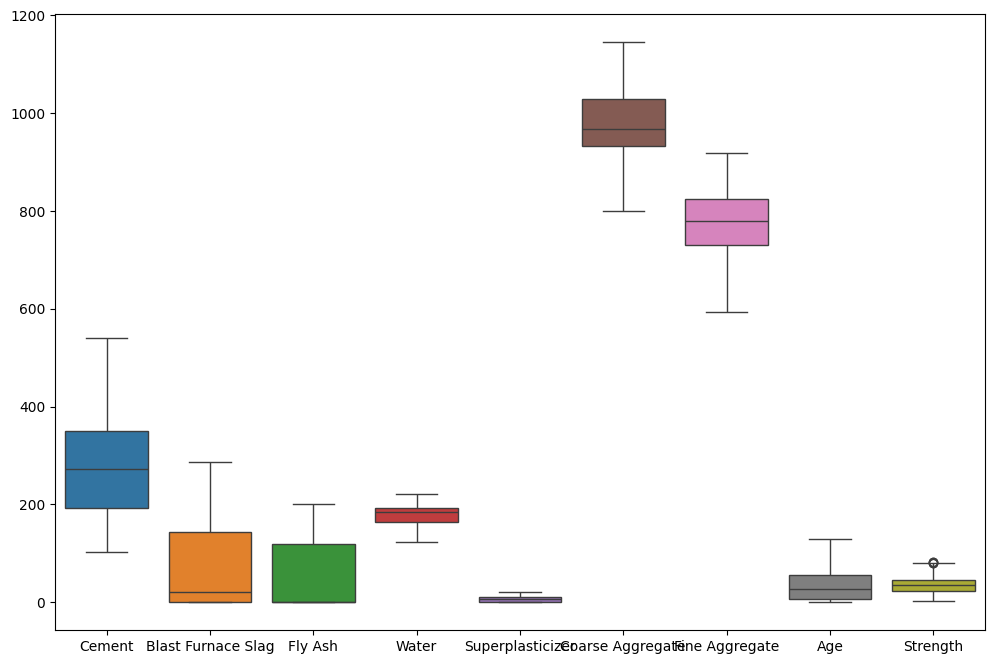

In [31]:
plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.show()

In [32]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

In [33]:
df["Age"].max()

129.5

In [34]:
df["Age"].min()

1.0

In [35]:
cols=['Blast Furnace Slag', 'Water', 'Superplasticizer', 'Fine Aggregate']

In [36]:
cols

['Blast Furnace Slag', 'Water', 'Superplasticizer', 'Fine Aggregate']

In [37]:
for c in cols:
  print(c)

Blast Furnace Slag
Water
Superplasticizer
Fine Aggregate


In [38]:
for c in cols:
  q1=df[c].quantile(0.25)
  q3=df[c].quantile(0.75)
  iqr=q3-q1
  lower=q1-(1.5*iqr)
  upper=q3+(1.5+iqr)
  df[c]=df[c].map(lambda x:lower if x<lower else upper if x>upper else x)

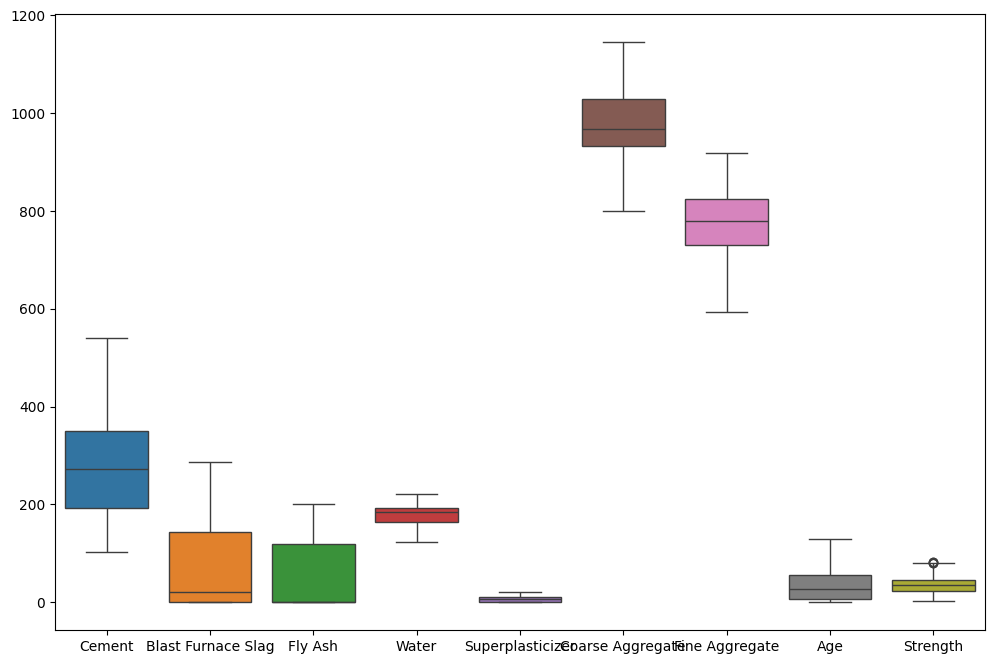

In [39]:
plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.show()

In [40]:
df["Age"]

,Age
0,28.0
1,28.0
2,129.5
3,129.5
4,129.5
...,...
1025,28.0
1026,28.0
1027,28.0
1028,28.0


In [41]:
q1_age=df["Age"].quantile(0.25)
q3_age=df["Age"].quantile(0.75)
iqr_age=q3_age-q1_age
lower_age=q1_age-(1.5*iqr_age)
upper_age=q3_age+(1.5*iqr_age)

In [42]:
lower_age

np.float64(-66.5)

In [43]:
upper_age

np.float64(129.5)

In [44]:
df[df["Age"]<lower_age ]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength


In [45]:
df[df["Age"]>upper_age ]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength


In [46]:
len(df[df["Age"]>upper_age ])

0

In [47]:
df[df["Age"]>upper_age ].count()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [48]:
df["Age"]=df["Age"].map(lambda x:lower_age if x<lower_age else upper_age if x>upper_age else x)

<Axes: ylabel='Age'>

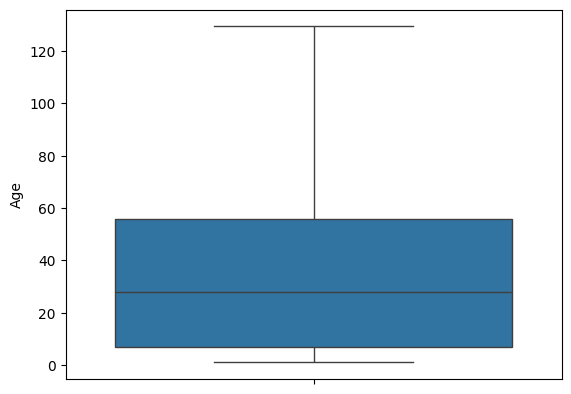

In [49]:
sns.boxplot(df["Age"])

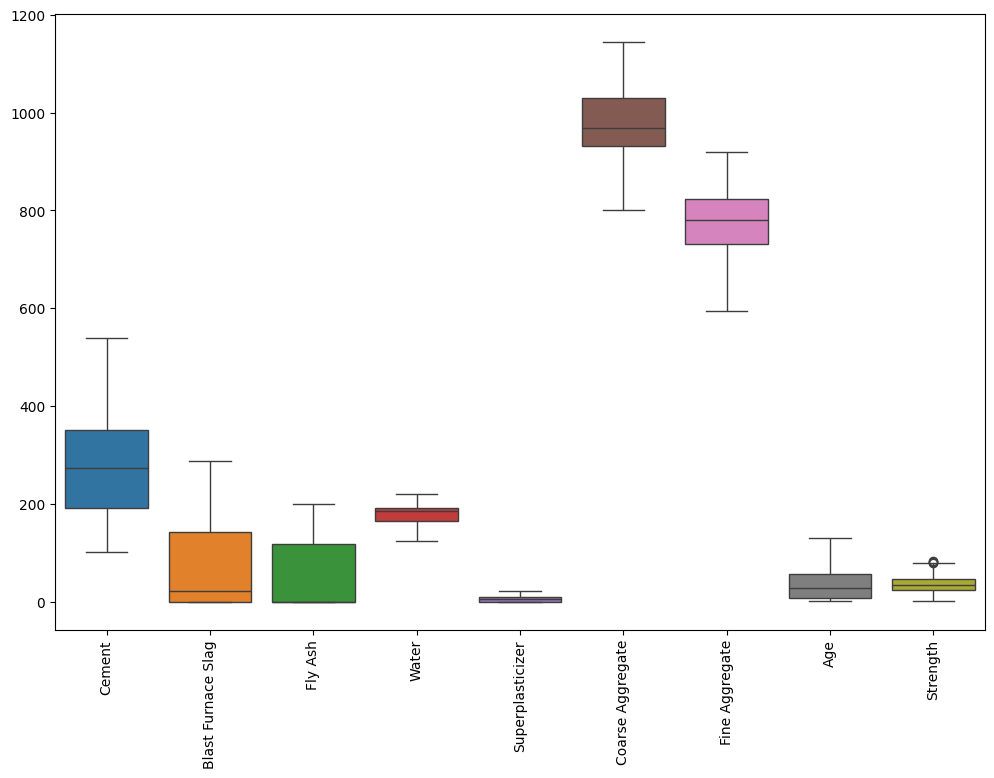

In [50]:
plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

#Data Seperation:

In [51]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0,61.89
2,332.5,142.5,0.0,220.6,0.0,932.0,594.0,129.5,40.27
3,332.5,142.5,0.0,220.6,0.0,932.0,594.0,129.5,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,129.5,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28.0,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28.0,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28.0,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28.0,32.77


In [52]:
x=df.drop("Strength",axis=1)

In [53]:
y=df["Strength"]

#Data Spliting:

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [56]:
x.shape

(1030, 8)

In [57]:
x_train.shape

(824, 8)

In [58]:
x_test.shape

(206, 8)

#Scaling:

In [59]:
from sklearn.preprocessing import StandardScaler

In [60]:
ss=StandardScaler() #scaling only for independent columns

In [61]:
ss

StandardScaler()

In [62]:
x_train_ss=ss.fit_transform(x_train)

In [63]:
x_test_ss=ss.transform(x_test)

In [64]:
x_train_ss

array([[-1.16087734,  0.87250578,  0.9824489 , ..., -0.25746155,
        -0.65086717, -0.27964442],
       [ 1.30862304, -0.60546721,  1.23259821, ..., -1.92694961,
        -0.26952933, -0.27964442],
       [-0.0768653 , -0.86169578,  1.06687429, ...,  1.01785948,
         0.07656937, -0.98804026],
       ...,
       [-0.86591441, -0.86169578,  1.12628475, ...,  1.34082214,
         0.34589709,  1.76053561],
       [ 1.78316909,  0.52193851, -0.83113361, ..., -1.54422615,
         0.126911  , -0.27964442],
       [ 0.28509237, -0.86169578,  0.9355459 , ..., -0.6172979 ,
         0.14578911, -0.27964442]])

In [65]:
x_test_ss

array([[-0.1615392 ,  0.46603409, -0.83113361, ..., -0.52829244,
        -1.27636192,  2.59644271],
       [ 0.73730683,  1.33954059, -0.83113361, ..., -0.36681111,
        -0.19653397, -0.87469693],
       [ 0.99132853,  1.33954059, -0.83113361, ..., -0.36681111,
        -0.19653397, -0.27964442],
       ...,
       [ 0.02734873,  1.47813695, -0.83113361, ...,  0.39482129,
         0.40630705, -0.87469693],
       [ 1.30862304, -0.60546721,  1.23259821, ..., -1.92694961,
        -0.26952933,  0.51375893],
       [ 0.51771297, -0.86169578, -0.83113361, ..., -0.07055009,
         0.1206183 ,  1.47717727]])

In [66]:
x_train.shape

(824, 8)

In [67]:
x_train.shape[1]

8

#Model Building:

In [68]:
from tensorflow.keras.models import Sequential

In [69]:
from tensorflow.keras.layers import Dense

In [70]:
smodel=Sequential()

In [71]:
smodel.add(Dense(64, activation="relu", input_shape=(x_train.shape[1],)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
smodel.add(Dense(32,activation="relu"))

#regression problem no activation function in output layer:

In [73]:
smodel.add(Dense(1))

In [74]:
smodel.compile(optimizer="adam",
               loss="mean_squared_error")

In [75]:
smodel.fit(x_train_ss,y_train,epochs=30,validation_split=0.2,verbose=0)

In [76]:
smodel.evaluate(x_test_ss,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 96.9328


96.59781646728516

In [78]:
np.sqrt(96.5978)

np.float64(9.828417980529725)